# MiniViT on CIFAR-10

This notebook builds a small Vision Transformer (ViT) from PyTorch components and trains it to classify CIFAR-10 images. A 32×32 image is split into 4×4 patches, producing 64 patch tokens. A learnable class token summarizes the image after the Transformer encoder.

In [1]:
from pathlib import Path
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"PyTorch: {torch.__version__} | device: {device}")

PyTorch: 2.2.1+cu121 | device: cuda


## Load CIFAR-10

Training images use random crops and horizontal flips. Both splits are normalized with CIFAR-10 channel statistics. Set `QUICK_RUN = True` to test the pipeline for one epoch on a subset before running the full experiment.

In [2]:
QUICK_RUN = False
BATCH_SIZE = 128
NUM_WORKERS = 2
EPOCHS = 1 if QUICK_RUN else 20

# Resolve paths whether the notebook is launched from the repository root or its own folder.
DATA_DIR = Path("../data") if Path("../data").exists() else Path("data")
CHECKPOINT_DIR = Path("output")
CHECKPOINT_DIR.mkdir(exist_ok=True)

mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_dataset = datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=test_transform)
if QUICK_RUN:
    train_dataset = torch.utils.data.Subset(train_dataset, range(4096))
    test_dataset = torch.utils.data.Subset(test_dataset, range(1024))

loader_kwargs = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=device.type == "cuda")
train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)
class_names = datasets.CIFAR10(DATA_DIR, train=False, download=False).classes
print(f"Training images: {len(train_dataset):,} | test images: {len(test_dataset):,}")
print(class_names)

Files already downloaded and verified
Files already downloaded and verified
Training images: 50,000 | test images: 10,000
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


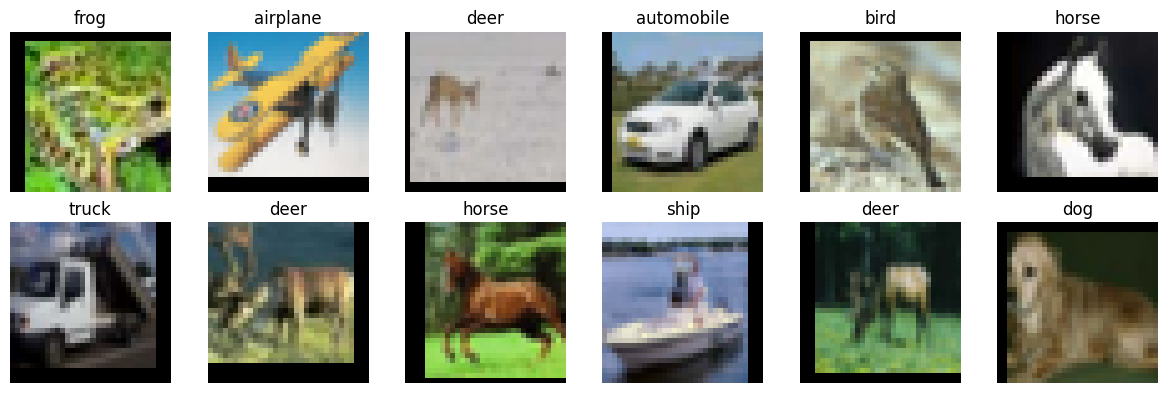

In [3]:
# Display unnormalized examples.
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for image, label, ax in zip(images[:12], labels[:12], axes.flat):
    image = image.permute(1, 2, 0) * torch.tensor(std) + torch.tensor(mean)
    ax.imshow(image.clamp(0, 1))
    ax.set_title(class_names[label])
    ax.axis("off")
plt.tight_layout()

# Vision Transformer (ViT) Model

An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale 

[Paper](https://arxiv.org/abs/2010.11929)
[Github repo](https://github.com/lucidrains/vit-pytorch/blob/main/vit_pytorch/vit.py) 


In [ ]:
import torch
from torch import nn
from torch.nn import Module, ModuleList

from einops import rearrange, repeat
from einops.layers.torch import Rearrange

# helpers

def pair(t):
    return t if isinstance(t, tuple) else (t, t)

# classes

class FeedForward(Module):
    def __init__(self, dim, hidden_dim, dropout = 0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

class Attention(Module):
    def __init__(self, dim, heads = 8, dim_head = 64, dropout = 0.):
        super().__init__()
        inner_dim = dim_head *  heads
        project_out = not (heads == 1 and dim_head == dim)

        self.heads = heads
        self.scale = dim_head ** -0.5

        self.norm = nn.LayerNorm(dim)

        self.attend = nn.Softmax(dim = -1)
        self.dropout = nn.Dropout(dropout)

        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias = False)

        self.to_out = nn.Sequential(
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        ) if project_out else nn.Identity()

    def forward(self, x):
        x = self.norm(x)

        qkv = self.to_qkv(x).chunk(3, dim = -1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h = self.heads), qkv)

        dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale

        attn = self.attend(dots)
        attn = self.dropout(attn)

        out = torch.matmul(attn, v)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)

class Transformer(Module):
    def __init__(self, dim, depth, heads, dim_head, mlp_dim, dropout = 0.):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.layers = ModuleList([])

        for _ in range(depth):
            self.layers.append(ModuleList([
                Attention(dim, heads = heads, dim_head = dim_head, dropout = dropout),
                FeedForward(dim, mlp_dim, dropout = dropout)
            ]))

    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x

        return self.norm(x)

class ViT(Module):
    def __init__(self, *, image_size, patch_size, num_classes, dim, depth, heads, mlp_dim, pool = 'cls', channels = 3, dim_head = 64, dropout = 0., emb_dropout = 0.):
        super().__init__()
        image_height, image_width = pair(image_size)
        self.patch_size = patch_height, patch_width = pair(patch_size)

        assert image_height % patch_height == 0 and image_width % patch_width == 0, 'Image dimensions must be divisible by the patch size.'

        num_patches = (image_height // patch_height) * (image_width // patch_width)
        patch_dim = channels * patch_height * patch_width

        assert pool in {'cls', 'mean'}, 'pool type must be either cls (cls token) or mean (mean pooling)'
        num_cls_tokens = 1 if pool == 'cls' else 0

        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1 = patch_height, p2 = patch_width),
            nn.LayerNorm(patch_dim),
            nn.Linear(patch_dim, dim),
            nn.LayerNorm(dim),
        )

        self.cls_token = nn.Parameter(torch.randn(num_cls_tokens, dim))
        self.pos_embedding = nn.Parameter(torch.randn(num_patches + num_cls_tokens, dim))

        self.dropout = nn.Dropout(emb_dropout)

        self.transformer = Transformer(dim, depth, heads, dim_head, mlp_dim, dropout)

        self.pool = pool
        self.to_latent = nn.Identity()

        self.mlp_head = nn.Linear(dim, num_classes) if num_classes > 0 else None

    def forward(self, img):
        batch = img.shape[0]
        x = self.to_patch_embedding(img)

        cls_tokens = repeat(self.cls_token, '... d -> b ... d', b = batch)
        x = torch.cat((cls_tokens, x), dim = 1)

        seq = x.shape[1]

        x = x + self.pos_embedding[:seq]
        x = self.dropout(x)

        x = self.transformer(x)

        if self.mlp_head is None:
            return x

        x = x.mean(dim = 1) if self.pool == 'mean' else x[:, 0]

        x = self.to_latent(x)
        return self.mlp_head(x)

model = ViT(
    image_size=32, 
    patch_size=4, 
    num_classes=10, 
    dim=192, 
    depth=6, 
    heads=6, 
    mlp_dim=768
).to(device)
parameter_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
with torch.no_grad():
    output_shape = model(torch.randn(2, 3, 32, 32, device=device)).shape
print(model)
print(f"Trainable parameters: {parameter_count / 1e6:.2f}M | output shape: {tuple(output_shape)}")

ViT(
  (to_patch_embedding): Sequential(
    (0): Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=4, p2=4)
    (1): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
    (2): Linear(in_features=48, out_features=192, bias=True)
    (3): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  )
  (dropout): Dropout(p=0.0, inplace=False)
  (transformer): Transformer(
    (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
    (layers): ModuleList(
      (0-5): 6 x ModuleList(
        (0): Attention(
          (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
          (attend): Softmax(dim=-1)
          (dropout): Dropout(p=0.0, inplace=False)
          (to_qkv): Linear(in_features=192, out_features=1152, bias=False)
          (to_out): Sequential(
            (0): Linear(in_features=384, out_features=192, bias=True)
            (1): Dropout(p=0.0, inplace=False)
          )
        )
        (1): FeedForward(
          (net): Sequential(
            (0): L

## Train and evaluate

AdamW is commonly used for Transformers. A cosine schedule gradually reduces the learning rate, while gradient clipping protects against unstable updates. The checkpoint with the best test accuracy is saved.

In [8]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

def run_epoch(model, loader, training):
    model.train(training)
    total_loss = total_correct = total_examples = 0
    context = torch.enable_grad() if training else torch.inference_mode()
    with context:
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            if training:
                optimizer.zero_grad(set_to_none=True)
            logits = model(inputs)
            loss = criterion(logits, targets)
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * targets.size(0)
            total_correct += (logits.argmax(dim=1) == targets).sum().item()
            total_examples += targets.size(0)
    return total_loss / total_examples, total_correct / total_examples

history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
best_accuracy = 0.0
checkpoint_path = CHECKPOINT_DIR / "minivit_cifar10_best.pt"

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    train_loss, train_acc = run_epoch(model, train_loader, training=True)
    test_loss, test_acc = run_epoch(model, test_loader, training=False)
    scheduler.step()
    for key, value in zip(history, (train_loss, train_acc, test_loss, test_acc)):
        history[key].append(value)
    if test_acc > best_accuracy:
        best_accuracy = test_acc
        torch.save({"model_state_dict": model.state_dict(), "test_accuracy": test_acc}, checkpoint_path)
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | {time.time() - start:5.1f}s | "
        f"train loss {train_loss:.4f}, acc {train_acc:.2%} | "
        f"test loss {test_loss:.4f}, acc {test_acc:.2%}"
    )

print(f"Best test accuracy: {best_accuracy:.2%}")
print(f"Saved checkpoint: {checkpoint_path.resolve()}")

Epoch 01/20 |   9.3s | train loss 1.8056, acc 38.77% | test loss 1.5844, acc 50.13%
Epoch 02/20 |   9.0s | train loss 1.5691, acc 50.86% | test loss 1.4855, acc 55.00%
Epoch 03/20 |   9.2s | train loss 1.4780, acc 55.17% | test loss 1.4197, acc 58.07%
Epoch 04/20 |   9.0s | train loss 1.4143, acc 58.22% | test loss 1.3556, acc 60.99%
Epoch 05/20 |   9.2s | train loss 1.3657, acc 60.60% | test loss 1.3277, acc 61.60%
Epoch 06/20 |   9.1s | train loss 1.3276, acc 62.26% | test loss 1.2838, acc 64.53%
Epoch 07/20 |   9.1s | train loss 1.2944, acc 63.76% | test loss 1.2397, acc 66.31%
Epoch 08/20 |   9.2s | train loss 1.2569, acc 65.60% | test loss 1.2266, acc 67.28%
Epoch 09/20 |   9.1s | train loss 1.2226, acc 67.38% | test loss 1.2242, acc 66.96%
Epoch 10/20 |   9.4s | train loss 1.1991, acc 68.36% | test loss 1.1965, acc 69.34%
Epoch 11/20 |   9.4s | train loss 1.1745, acc 69.58% | test loss 1.1777, acc 70.34%
Epoch 12/20 |   9.2s | train loss 1.1553, acc 70.33% | test loss 1.1528, acc

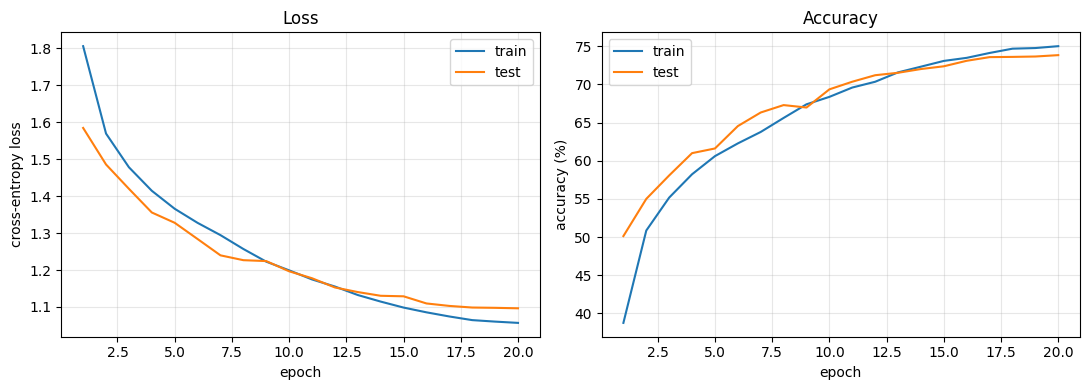

In [9]:
epochs = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, history["train_loss"], label="train")
axes[0].plot(epochs, history["test_loss"], label="test")
axes[0].set(xlabel="epoch", ylabel="cross-entropy loss", title="Loss")
axes[1].plot(epochs, np.array(history["train_acc"]) * 100, label="train")
axes[1].plot(epochs, np.array(history["test_acc"]) * 100, label="test")
axes[1].set(xlabel="epoch", ylabel="accuracy (%)", title="Accuracy")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()